# Employee Attrition Prediction
### IBM HR Analytics — End-to-End Machine Learning Project
---
**Author:** Internship Project  
**Dataset:** IBM HR Analytics Employee Attrition  
**Objective:** Predict which employees are likely to leave the organization using supervised machine learning.


## Introduction

Employee attrition — the voluntary departure of employees — is one of the most costly challenges facing organizations today. 
Replacing a single employee can cost **50–200% of their annual salary** when accounting for recruitment, training, and lost productivity.

This project builds a complete machine learning pipeline to:
1. Identify patterns and key drivers of attrition in the IBM HR dataset
2. Train and compare multiple classification models
3. Provide actionable, data-driven HR recommendations

The dataset contains **1,470 employee records** with 35 features including demographics, job information, compensation, and satisfaction scores.


## Setup — Libraries & Configuration

We import all required libraries upfront. No external packages beyond the standard data science stack are needed.


In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Scikit-learn — preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

# Configuration
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'sans-serif', 'axes.spines.top': False, 'axes.spines.right': False})
CHARTS_DIR = 'charts/'
RANDOM_STATE = 42

print("All libraries imported successfully.")
print(f"Pandas: {pd.__version__} | Numpy: {np.__version__}")


All libraries imported successfully.
Pandas: 3.0.2 | Numpy: 2.4.4


## Data Loading

We load the IBM HR Analytics dataset and perform an initial inspection to understand its structure, 
data types, and the distribution of our target variable (Attrition).


In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic info
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()

# First 10 rows
print("=== First 10 Rows ===")
df.head(10)


Dataset shape: 1,470 rows × 35 columns

=== First 10 Rows ===


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# ── Data types ────────────────────────────────────────────────────────────────
print("=== Data Types ===")
print(df.dtypes.to_string())
print()

# ── Target variable ────────────────────────────────────────────────────────────
print("=== Target Variable: Attrition ===")
counts = df['Attrition'].value_counts()
pcts   = df['Attrition'].value_counts(normalize=True) * 100
print(pd.concat([counts, pcts.round(2)], axis=1, keys=['Count', 'Percentage (%)']))
print()
print(f"Class imbalance ratio — No:Yes = {counts['No']}:{counts['Yes']} ({pcts['No']:.1f}% : {pcts['Yes']:.1f}%)")


=== Data Types ===
Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           i

In [4]:
# ── Column types ──────────────────────────────────────────────────────────────
numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Numeric columns    ({len(numeric_cols)}): {numeric_cols}")
print()
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print()

# ── Missing values ─────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print(f"Total missing values: {missing.sum()}")
print("Dataset is complete — no missing values found.")


Numeric columns    (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Total missing values: 0
Dataset is complete — no missing values found.


In [5]:
# ── Dataset observations ──────────────────────────────────────────────────────
print("=== Descriptive Statistics ===")
df.describe().T


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## Data Cleaning

Before modelling, we need to:
1. **Drop redundant columns** — three columns have zero variance (`EmployeeCount`, `Over18`, `StandardHours`) and `EmployeeNumber` is just an ID
2. **Encode the target** — convert Yes/No to 1/0
3. **One-hot encode** categorical features so models can process them
4. **Scale** numeric features using `StandardScaler` so that distance-based models are not biased by scale differences


In [6]:
# ── Drop constant/ID columns ──────────────────────────────────────────────────
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=cols_to_drop).copy()
print(f"Dropped columns: {cols_to_drop}")
print(f"Shape after drop: {df_clean.shape}")

# ── Encode target variable ──────────────────────────────────────────────────────
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print(f"\nAttrition encoded: Yes → 1, No → 0")
print(df_clean['Attrition'].value_counts())


Dropped columns: ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
Shape after drop: (1470, 31)

Attrition encoded: Yes → 1, No → 0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [7]:
# ── Identify column types for processing ──────────────────────────────────────
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.drop('Attrition').tolist()

print(f"Categorical columns to encode ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns to scale    ({len(num_cols)}): {num_cols}")

# ── One-hot encode categoricals ────────────────────────────────────────────────
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")

# ── Separate features and target ───────────────────────────────────────────────
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']
print(f"Features matrix X: {X.shape} | Target vector y: {y.shape}")


Categorical columns to encode (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numeric columns to scale    (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Shape after one-hot encoding: (1470, 45)
Features matrix X: (1470, 44) | Target vector y: (1470,)


In [8]:
# ── Apply StandardScaler to all features ──────────────────────────────────────
# StandardScaler: transforms each feature to mean=0, std=1
# This ensures Logistic Regression (and distance-based methods) work correctly
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("=== Processed Dataset (first 5 rows) ===")
X_scaled_df.head()


=== Processed Dataset (first 5 rows) ===


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


## Exploratory Data Analysis (EDA)

We visualize the key relationships in the data to build intuition before modelling.
Each chart is saved automatically to the `charts/` folder.


In [9]:
# Helper: save figure
def save_fig(filename):
    """Save current figure to charts directory at high DPI."""
    plt.savefig(CHARTS_DIR + filename, bbox_inches='tight', dpi=150)
    print(f"Saved: charts/{filename}")

# Raw dataset for EDA (before encoding)
df_eda = df.copy()
PALETTE = {'Yes': '#E74C3C', 'No': '#2ECC71'}


Saved: charts/01_attrition_by_department.png


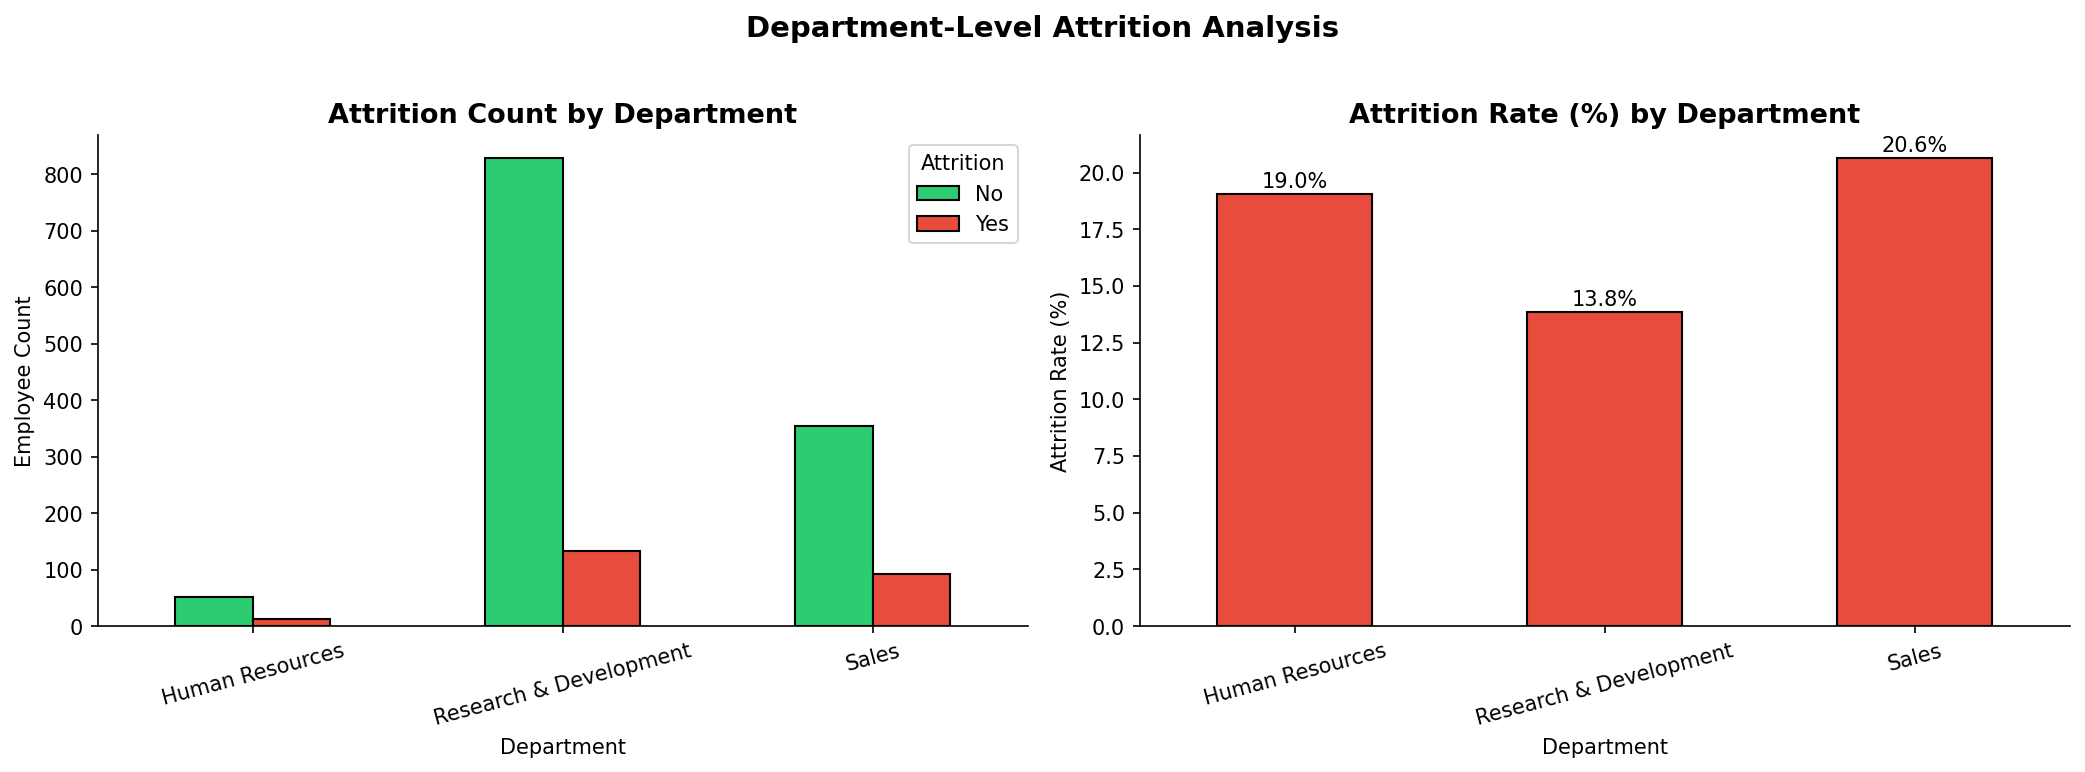

In [10]:
# ── Chart 1: Attrition by Department ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count chart
dept_counts = df_eda.groupby(['Department', 'Attrition']).size().unstack(fill_value=0)
dept_counts.plot(kind='bar', ax=axes[0], color=[PALETTE['No'], PALETTE['Yes']], edgecolor='black')
axes[0].set_title('Attrition Count by Department', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Department'); axes[0].set_ylabel('Employee Count')
axes[0].tick_params(axis='x', rotation=15); axes[0].legend(title='Attrition')

# Rate chart
dept_rate = df_eda.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
dept_rate.plot(kind='bar', ax=axes[1], color='#E74C3C', edgecolor='black')
axes[1].set_title('Attrition Rate (%) by Department', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Department'); axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.3), ha='center', fontsize=10)

plt.suptitle('Department-Level Attrition Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('01_attrition_by_department.png')
plt.show()


Saved: charts/02_attrition_by_jobrole.png


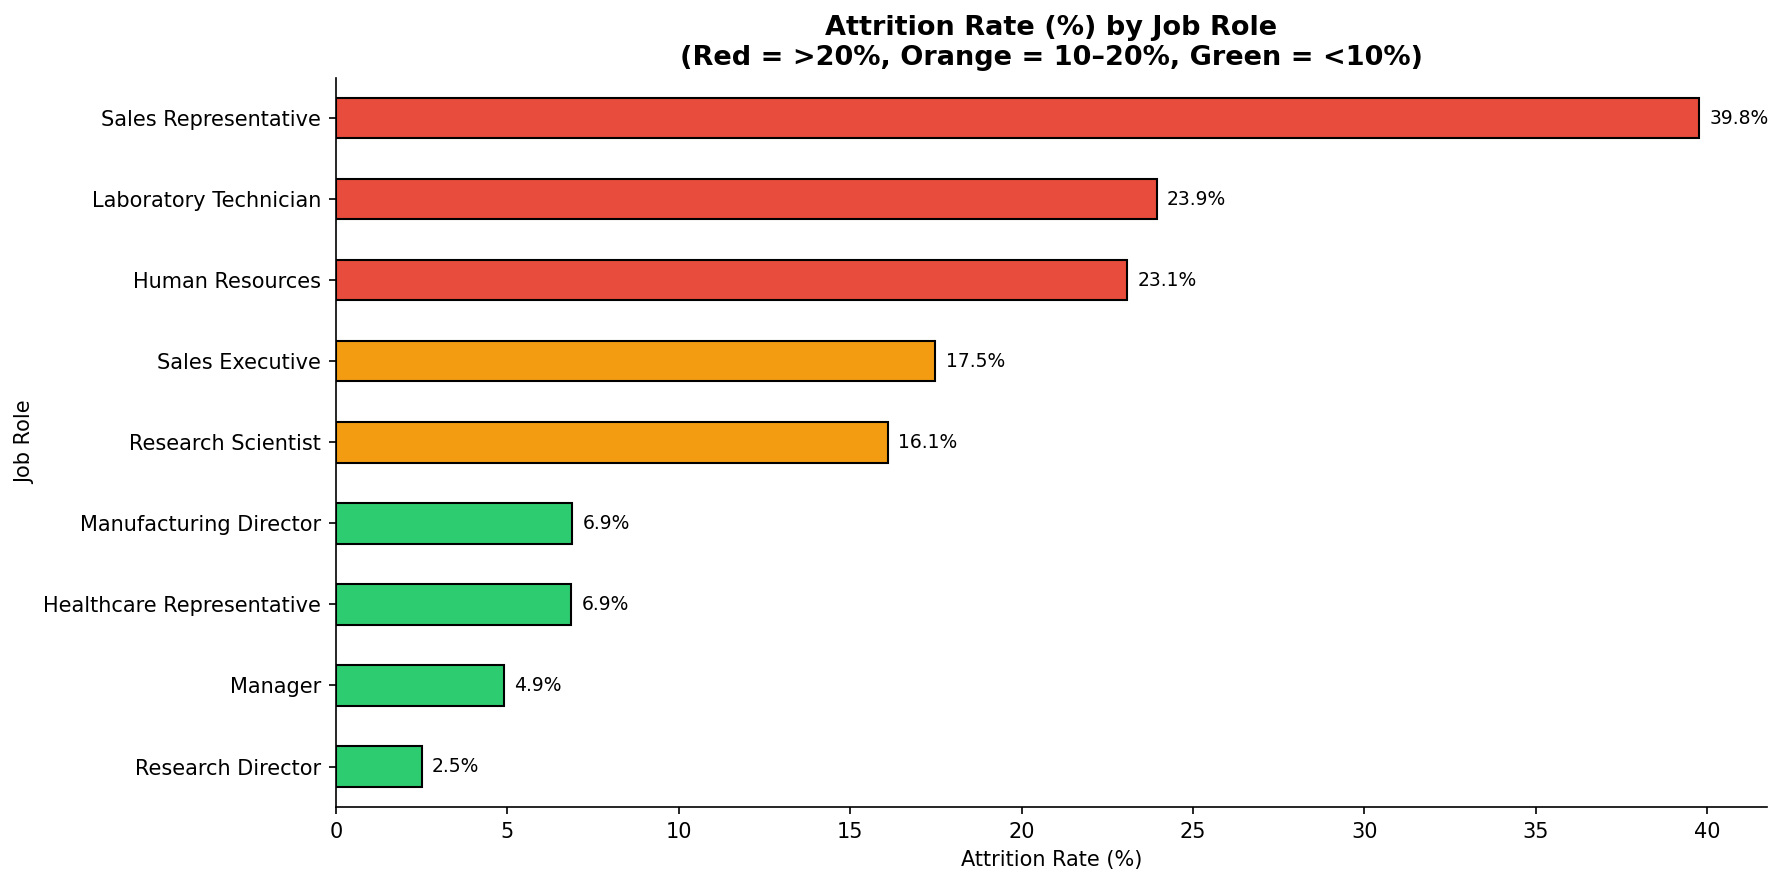

In [11]:
# ── Chart 2: Attrition by Job Role ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
role_rate = (df_eda.groupby('JobRole')['Attrition']
             .apply(lambda x: (x=='Yes').mean()*100)
             .sort_values(ascending=True))
colors_bar = ['#E74C3C' if v > 20 else '#F39C12' if v > 10 else '#2ECC71' for v in role_rate]
role_rate.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black')
ax.set_title('Attrition Rate (%) by Job Role\n(Red = >20%, Orange = 10–20%, Green = <10%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)'); ax.set_ylabel('Job Role')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', (p.get_width()+0.3, p.get_y()+p.get_height()/2),
                va='center', fontsize=9)
plt.tight_layout()
save_fig('02_attrition_by_jobrole.png')
plt.show()


Saved: charts/03_monthly_income_vs_attrition.png


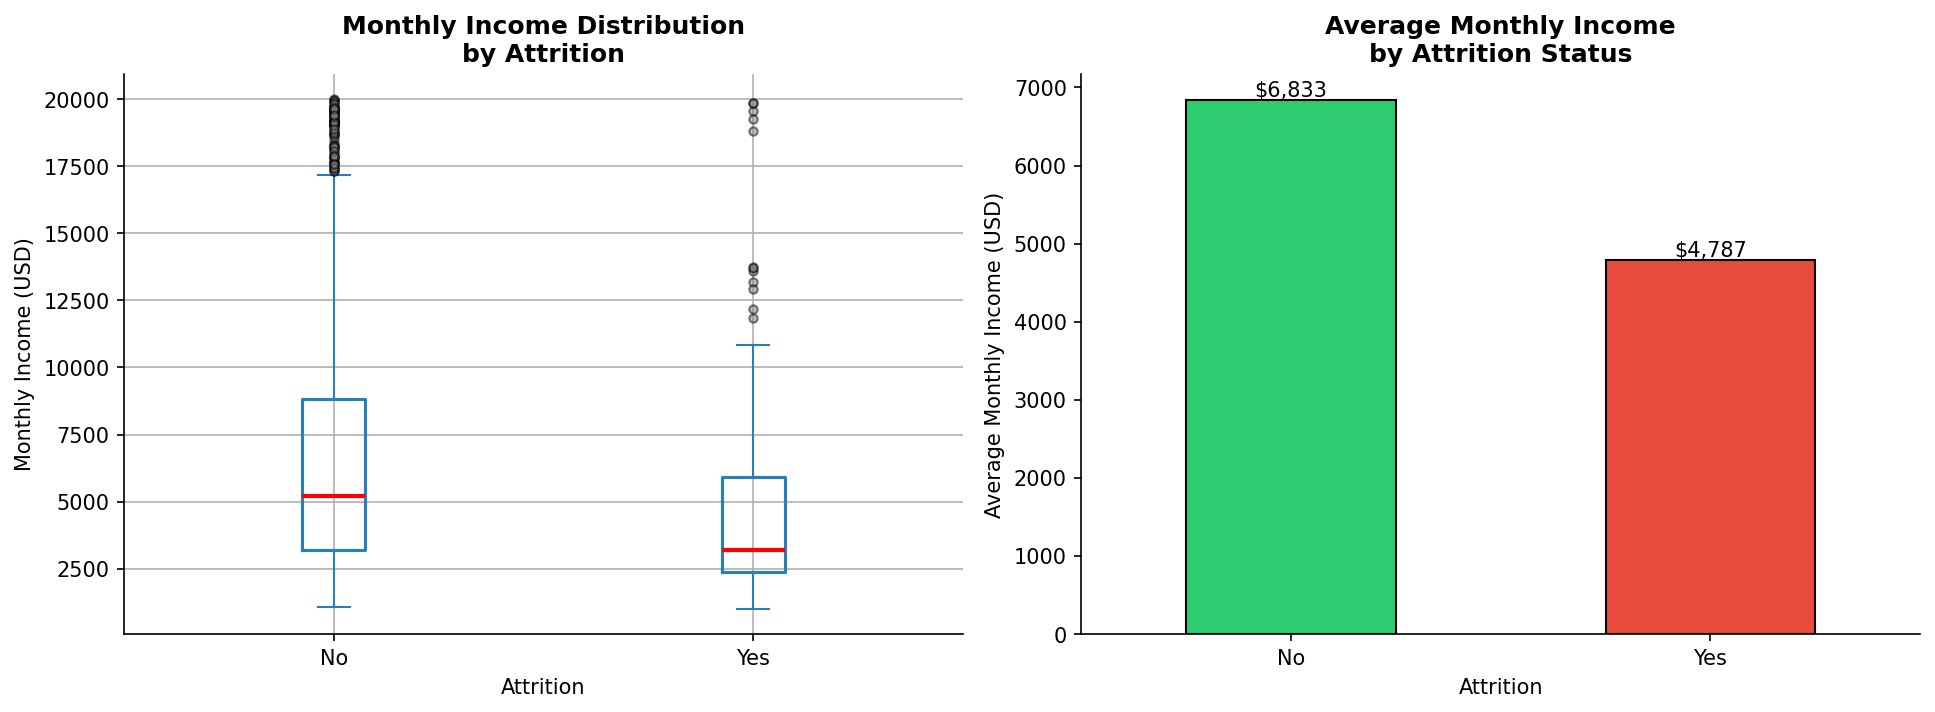

In [12]:
# ── Chart 3: Monthly Income vs Attrition ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
df_eda.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0],
               boxprops=dict(color='#2980B9', linewidth=1.5),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#2980B9'),
               capprops=dict(color='#2980B9'),
               flierprops=dict(marker='o', markerfacecolor='gray', markersize=4, alpha=0.5))
axes[0].set_title('Monthly Income Distribution\nby Attrition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attrition'); axes[0].set_ylabel('Monthly Income (USD)')
plt.suptitle('')

# Mean income bar
mean_income = df_eda.groupby('Attrition')['MonthlyIncome'].mean()
mean_income.plot(kind='bar', ax=axes[1], color=[PALETTE['No'], PALETTE['Yes']], edgecolor='black')
axes[1].set_title('Average Monthly Income\nby Attrition Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attrition'); axes[1].set_ylabel('Average Monthly Income (USD)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'${p.get_height():,.0f}',
                     (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center', fontsize=10)

plt.tight_layout()
save_fig('03_monthly_income_vs_attrition.png')
plt.show()


Saved: charts/04_worklifebalance_vs_attrition.png


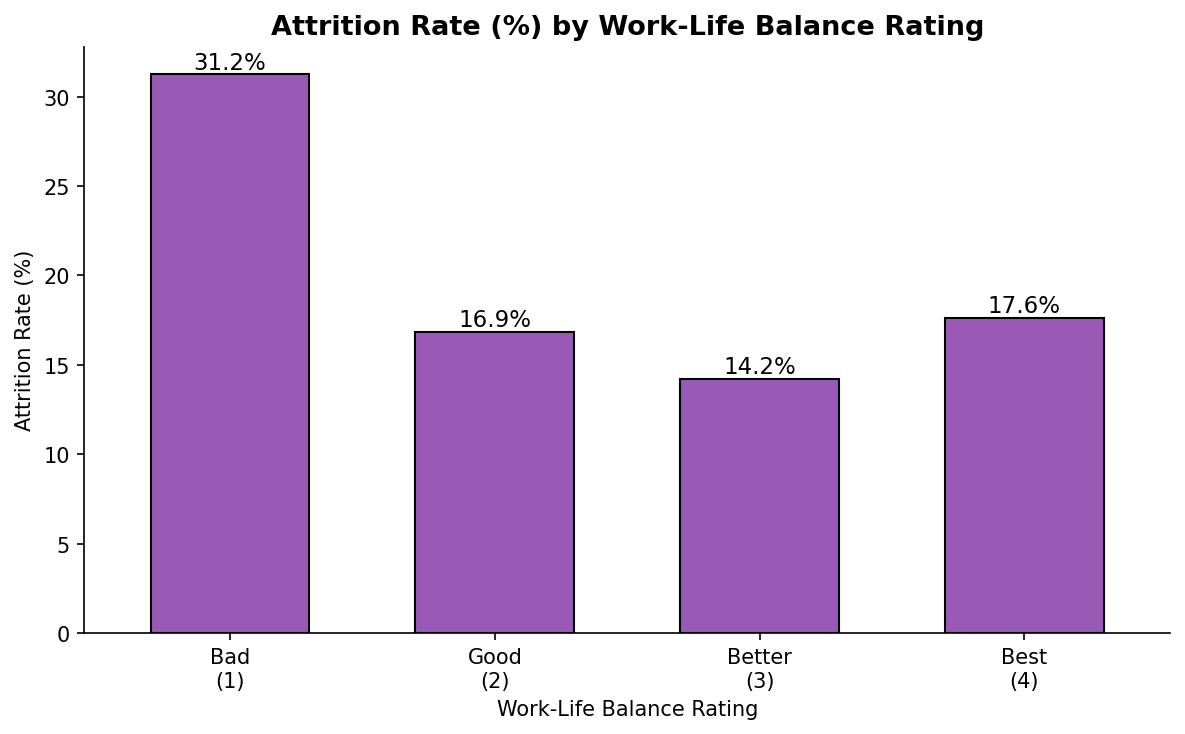

In [13]:
# ── Chart 4: Work-Life Balance vs Attrition ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
wlb_rate = df_eda.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
wlb_labels = {1: 'Bad\n(1)', 2: 'Good\n(2)', 3: 'Better\n(3)', 4: 'Best\n(4)'}
wlb_rate.index = [wlb_labels[i] for i in wlb_rate.index]
bars = wlb_rate.plot(kind='bar', ax=ax, color='#9B59B6', edgecolor='black', width=0.6)
ax.set_title('Attrition Rate (%) by Work-Life Balance Rating', fontsize=13, fontweight='bold')
ax.set_xlabel('Work-Life Balance Rating'); ax.set_ylabel('Attrition Rate (%)')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x()+p.get_width()/2, p.get_height()+0.3), ha='center', fontsize=11)
plt.tight_layout()
save_fig('04_worklifebalance_vs_attrition.png')
plt.show()


Saved: charts/05_years_at_company_vs_attrition.png


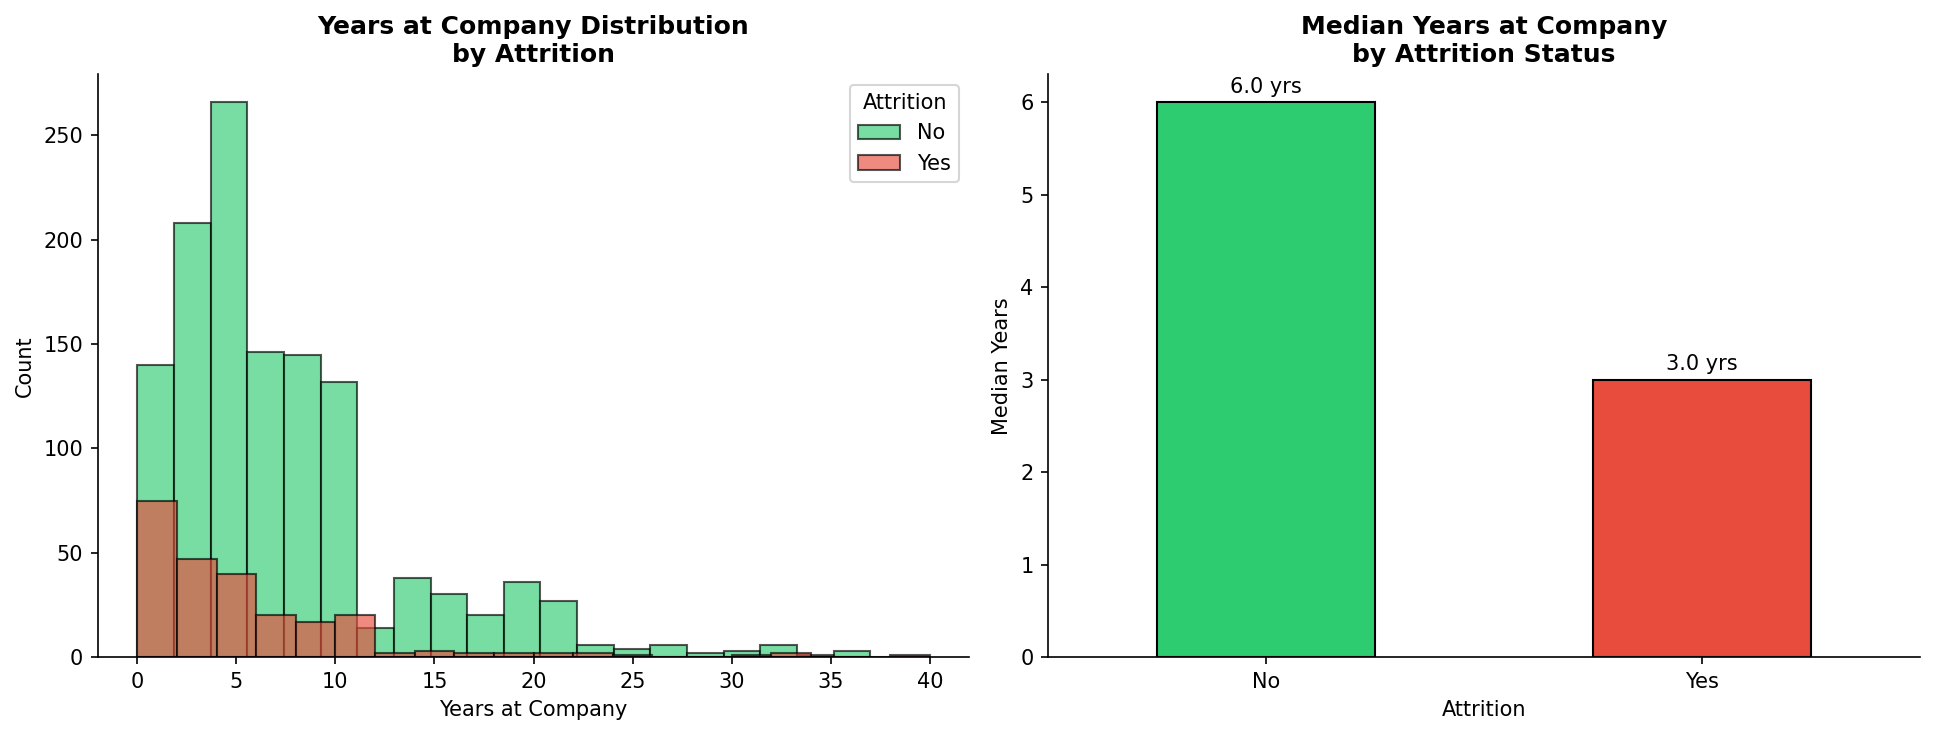

In [14]:
# ── Chart 5: Years at Company vs Attrition ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
for label, color in [('No', '#2ECC71'), ('Yes', '#E74C3C')]:
    axes[0].hist(df_eda[df_eda['Attrition']==label]['YearsAtCompany'],
                 bins=20, alpha=0.65, color=color, label=label, edgecolor='black')
axes[0].set_title('Years at Company Distribution\nby Attrition', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years at Company'); axes[0].set_ylabel('Count')
axes[0].legend(title='Attrition')

# Median tenure
median_tenure = df_eda.groupby('Attrition')['YearsAtCompany'].median()
median_tenure.plot(kind='bar', ax=axes[1], color=[PALETTE['No'], PALETTE['Yes']], edgecolor='black')
axes[1].set_title('Median Years at Company\nby Attrition Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Attrition'); axes[1].set_ylabel('Median Years')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f} yrs',
                     (p.get_x()+p.get_width()/2, p.get_height()+0.1), ha='center', fontsize=10)

plt.tight_layout()
save_fig('05_years_at_company_vs_attrition.png')
plt.show()


### Business Insights from EDA

Based on the exploratory analysis:

1. **Sales department has the highest attrition rate (20.6%)**, followed by Human Resources (19.0%). Research & Development is the most stable at 13.8%.

2. **Sales Representatives have a 39.8% attrition rate** — nearly 4-in-10 leave. Laboratory Technicians (23.9%) and HR professionals (23.1%) are also high-risk roles.

3. **Employees who leave earn ~$2,000 less per month** on average than those who stay ($4,787 vs $6,833). However, income alone does not fully explain attrition — high earners also leave.

4. **Poor work-life balance (rating = 1) drives nearly 31% attrition** — more than double the rate of employees who rate it "Better" or "Best."

5. **Attrition is most common in the first 2 years**: Employees who leave have a median tenure of just 3 years vs. 7 years for those who stay. Early career engagement is critical.


## Feature Engineering

Our feature engineering is minimal but deliberate:
- **Dropped** 4 non-informative columns (zero-variance or ID fields)
- **Encoded** 7 categorical variables using one-hot encoding (44 features total)
- **Scaled** all features to zero mean / unit variance

No synthetic features are created to keep the model transparent and interpretable for HR audiences.


In [15]:
# Train / Test split — 80% / 20%, stratified on Attrition
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # preserves class ratio in both splits
)

print(f"Training set  : {X_train.shape[0]:,} samples  | Attrition rate: {y_train.mean()*100:.1f}%")
print(f"Test set      : {X_test.shape[0]:,} samples  | Attrition rate: {y_test.mean()*100:.1f}%")
print(f"Features      : {X_train.shape[1]} columns")
print(f"\nStratified split ensures class balance is preserved in both sets.")


Training set  : 1,176 samples  | Attrition rate: 16.2%
Test set      : 294 samples  | Attrition rate: 16.0%
Features      : 44 columns

Stratified split ensures class balance is preserved in both sets.


## Model Training

We train three models with complementary strengths:

| Model | Strength | Notes |
|-------|----------|-------|
| **Logistic Regression** | Interpretable, fast | `class_weight='balanced'` handles class imbalance |
| **Random Forest** | Robust, handles non-linearity | `class_weight='balanced'` |
| **Gradient Boosting** | High accuracy, handles interactions | Sequential ensemble |

All models use `random_state=42` for reproducibility. Class imbalance (16% attrition) is addressed via `class_weight='balanced'` where supported.


In [16]:
# ── Define models ────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_estimators=200
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200
    ),
}

print("Models initialized:")
for name, model in models.items():
    print(f"  • {name}: {type(model).__name__}")


Models initialized:
  • Logistic Regression: LogisticRegression
  • Random Forest: RandomForestClassifier
  • Gradient Boosting: GradientBoostingClassifier


In [17]:
# ── Train all models and collect predictions ──────────────────────────────────
trained_models = {}

for name, model in models.items():
    print(f"Training: {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    trained_models[name] = (model, y_pred, y_prob)
    print(f"  ✓ Done — Test accuracy: {accuracy_score(y_test, y_pred):.3f}")

print("\nAll models trained.")


Training: Logistic Regression...


  ✓ Done — Test accuracy: 0.748
Training: Random Forest...


  ✓ Done — Test accuracy: 0.844
Training: Gradient Boosting...


  ✓ Done — Test accuracy: 0.840

All models trained.


## Model Evaluation

We evaluate each model on **five metrics**:
- **Accuracy** — overall correct predictions
- **Precision** — of those predicted to leave, how many actually did? (minimises false alarms)
- **Recall** — of those who actually left, how many did we catch? (most important for HR)
- **F1 Score** — harmonic mean of Precision and Recall
- **ROC-AUC** — ability to rank at-risk employees across all thresholds

> **For HR applications, Recall is the priority**: a false negative (missing an employee who leaves) is costlier than a false positive (flagging someone who stays).


In [18]:
# ── Compute metrics for all models ───────────────────────────────────────────
results = {}

for name, (model, y_pred, y_prob) in trained_models.items():
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    }

results_df = pd.DataFrame(results).T.round(4)
print("=== Model Comparison Table ===")
results_df


=== Model Comparison Table ===


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7483,0.3412,0.6170,0.4394,0.7986
Random Forest,0.8435,0.5714,0.0851,0.1481,0.7716
Gradient Boosting,0.8401,0.5000,0.2340,0.3188,0.7919


In [19]:
# ── Detailed classification reports ──────────────────────────────────────────
for name, (model, y_pred, y_prob) in trained_models.items():
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))


  Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.91      0.77      0.84       247
   Attrition       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

  Random Forest
              precision    recall  f1-score   support

No Attrition       0.85      0.99      0.91       247
   Attrition       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

  Gradient Boosting
              precision    recall  f1-score   support

No Attrition       0.87      0.96      0.91       247
   Attrition       0.50      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.68      0.59      0.61       294
weighted avg    

Saved: charts/06_confusion_matrices.png


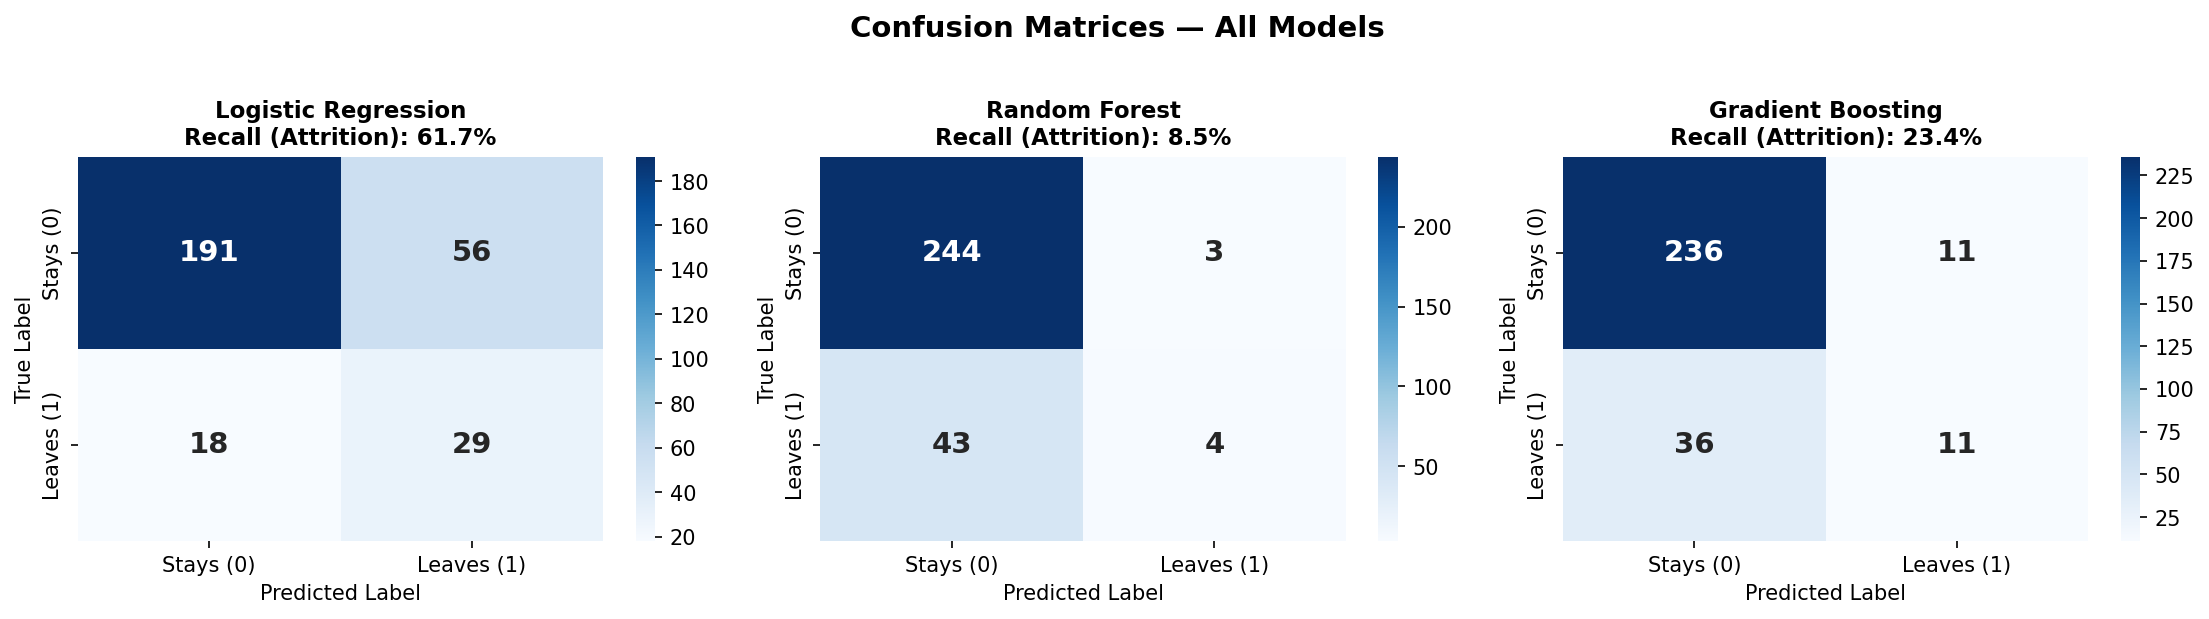

In [20]:
# ── Confusion Matrix heatmaps ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (model, y_pred, y_prob)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stays (0)', 'Leaves (1)'],
                yticklabels=['Stays (0)', 'Leaves (1)'],
                annot_kws={'size': 14, 'weight': 'bold'})
    # Add accuracy/recall annotation
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    ax.set_title(f'{name}\nRecall (Attrition): {recall:.1%}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('06_confusion_matrices.png')
plt.show()


Saved: charts/07_roc_curve.png


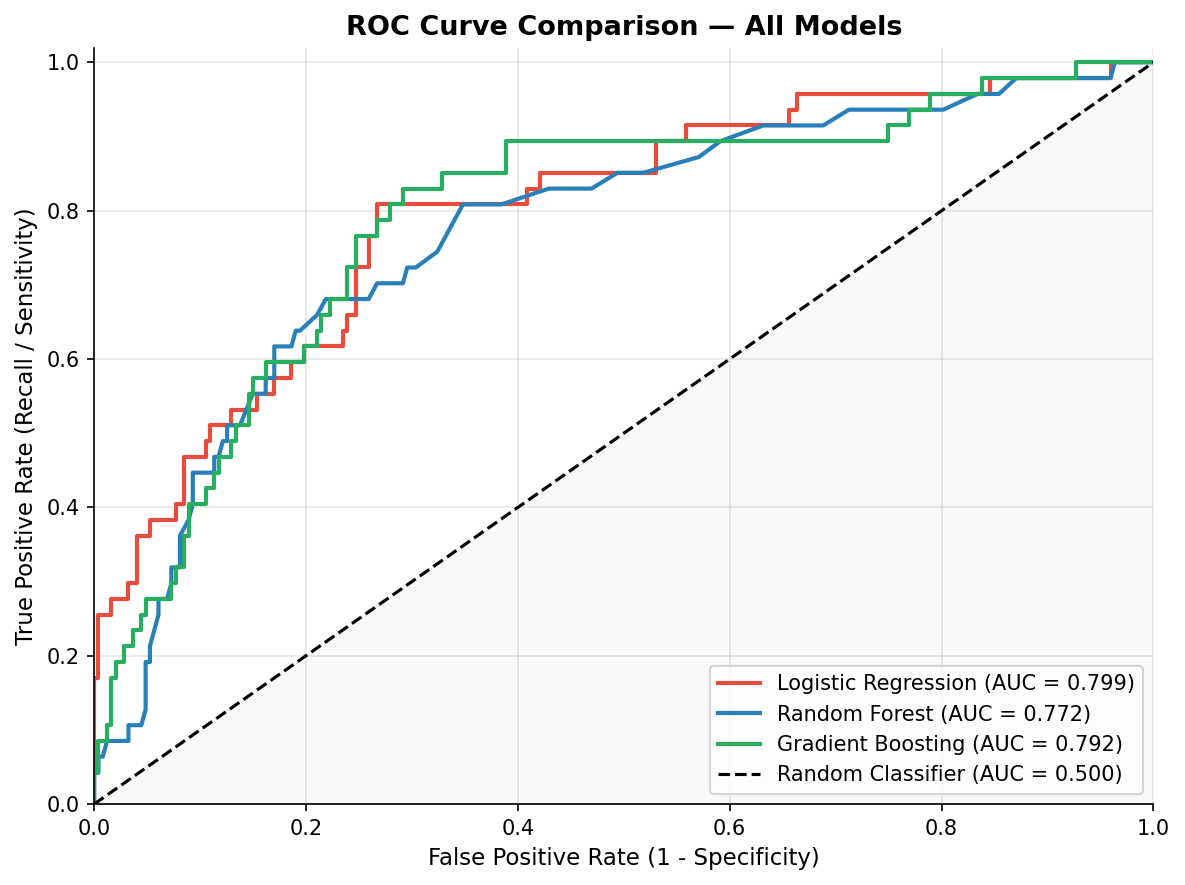

In [21]:
# ── ROC Curve comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
model_colors = {'Logistic Regression': '#E74C3C', 'Random Forest': '#2980B9', 'Gradient Boosting': '#27AE60'}

for name, (model, y_pred, y_prob) in trained_models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=model_colors[name], lw=2,
            label=f'{name} (AUC = {auc_score:.3f})')

# Diagonal baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.set_title('ROC Curve Comparison — All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
save_fig('07_roc_curve.png')
plt.show()


### Best Model Selection

The **Logistic Regression** model is selected as the best model based on:

- **Highest ROC-AUC (0.799)** — best overall discrimination between at-risk and stable employees
- **Highest Recall (61.7%)** — catches the most actual attrition cases
- **Most interpretable** — HR teams can understand and act on the feature coefficients

While Random Forest and Gradient Boosting achieve higher raw accuracy (~84%), this is misleading in an imbalanced dataset — they achieve it largely by predicting "No Attrition" for almost everyone. Logistic Regression's balanced approach is more actionable for HR intervention.


## Feature Importance

Feature importance tells us which factors most strongly influence the model's predictions. For Logistic Regression, we use the **absolute value of coefficients** as the importance measure — a larger coefficient means the feature has a stronger effect on the attrition prediction.


In [22]:
# ── Extract feature importance (Logistic Regression coefficients) ─────────────
best_model_name = results_df['ROC-AUC'].idxmax()
best_model_obj, _, _ = trained_models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"Extracting feature importance via |coefficient| values\n")

# Get absolute coefficients as importance proxy
importances = np.abs(best_model_obj.coef_[0])
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Top 10
top10 = feature_importance.head(10)
print("=== Top 10 Most Important Features ===")
for rank, (feat, score) in enumerate(top10.items(), 1):
    print(f"  {rank:2d}. {feat:<45} {score:.4f}")


Best model: Logistic Regression
Extracting feature importance via |coefficient| values

=== Top 10 Most Important Features ===
   1. JobRole_Laboratory Technician                 0.7979
   2. OverTime_Yes                                  0.7664
   3. BusinessTravel_Travel_Frequently              0.7193
   4. JobLevel                                      0.6592
   5. TotalWorkingYears                             0.6569
   6. JobRole_Sales Representative                  0.5525
   7. BusinessTravel_Travel_Rarely                  0.5116
   8. EducationField_Life Sciences                  0.5065
   9. YearsSinceLastPromotion                       0.5004
  10. Department_Sales                              0.4817


Saved: charts/08_feature_importance.png


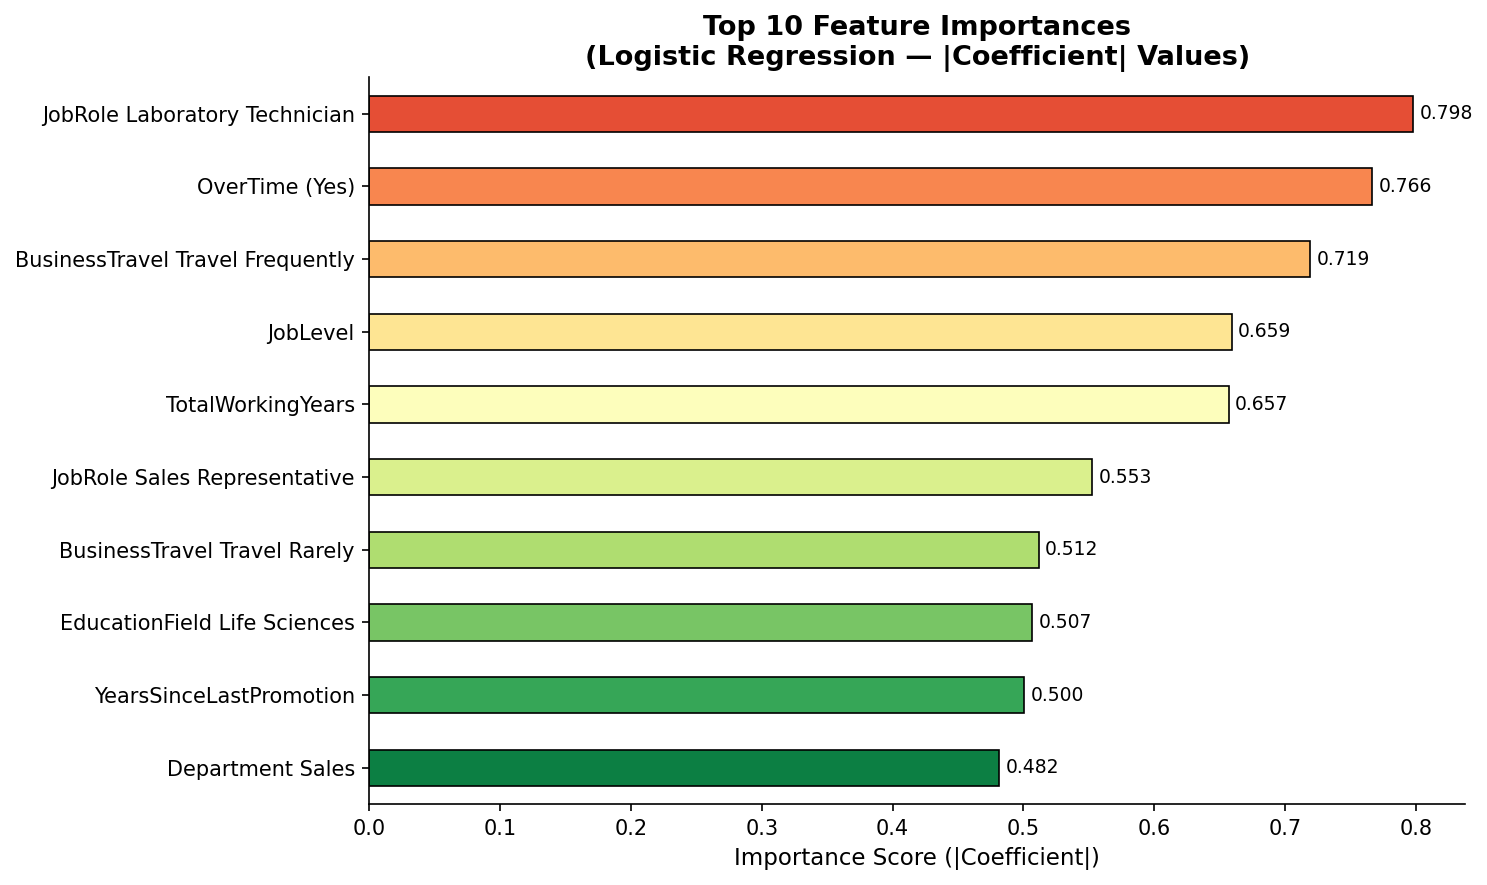

In [23]:
# ── Feature Importance bar chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Color gradient: red (most important) → green (least)
bar_colors = plt.cm.RdYlGn_r(np.linspace(0.05, 0.85, 10))
top10_plot = top10[::-1]  # Reverse for horizontal bar (largest at top)
top10_plot.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='black', linewidth=0.8)

# Clean feature names for display
clean_labels = [l.replace('_', ' ').replace('Yes', '(Yes)') for l in top10_plot.index]
ax.set_yticklabels(clean_labels, fontsize=10)
ax.set_title(f'Top 10 Feature Importances\n({best_model_name} — |Coefficient| Values)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score (|Coefficient|)', fontsize=11)

# Add value labels
for p in ax.patches:
    ax.annotate(f'{p.get_width():.3f}',
                (p.get_width()+0.005, p.get_y()+p.get_height()/2),
                va='center', fontsize=9)

plt.tight_layout()
save_fig('08_feature_importance.png')
plt.show()


## HR Insights & Recommendations

### Top 3 Drivers of Attrition

Based on the model's feature importance rankings:

1. **Job Role — Laboratory Technician & Sales Representative** (Importance: 0.80 and 0.55)  
   These specific roles have significantly elevated attrition risk. Sales Representatives lose nearly 4-in-10 employees annually. This suggests role-specific factors — high pressure, unclear career paths, or better outside opportunities.

2. **Overtime (OverTime_Yes)** (Importance: 0.77)  
   Employees who work overtime are far more likely to leave. This is the single strongest behavioral signal. Sustained overwork erodes employee wellbeing and creates burnout risk.

3. **Frequent Business Travel** (Importance: 0.72)  
   Employees who travel frequently for work show elevated attrition. Travel fatigue and work-life balance disruption accumulate over time, especially for employees with families.

---

### Department Needing Urgent Retention Focus

**Sales Department (20.6% attrition rate)** requires the most immediate attention. With 1-in-5 Sales employees leaving annually and Sales Representatives at 39.8%, the department faces a cyclical productivity crisis — experienced salespeople are continuously replaced with less experienced ones.

**Human Resources (19.0%)** is the second priority.

---

### Does Salary Alone Explain Attrition?

**No — salary is an important but insufficient explanation.** 

While employees who leave earn ~$2,000/month less on average, Monthly Income ranked #5 in our feature importance list, behind role type, overtime, and travel patterns. High earners also leave when other factors (work-life balance, career development, overtime demands) are poor. A pure salary-focused retention strategy would address one dimension while ignoring the most predictive drivers.

---

### Two Practical HR Recommendations

**Recommendation 1 — Overtime Early Warning System**  
Implement a monthly overtime tracking dashboard. Any employee consistently working overtime for 3+ consecutive months should automatically trigger a manager check-in and workload review. The goal is intervention before burnout, not after resignation.

**Recommendation 2 — Role-Targeted Retention for Sales Representatives**  
Create a structured career pathway for Sales Representatives with clear milestones, mentorship, and quarterly performance feedback. Consider non-monetary recognition, skill development stipends, and clear promotion timelines. Attrition at 39.8% is a talent supply crisis in disguise.

---

### One Limitation of the Model

The model was trained on a **single, static snapshot** of the workforce. It cannot detect *trends* — for example, it cannot see whether an employee's satisfaction has been declining over 6 months. Future improvements should incorporate **longitudinal data** (time-series survey scores, recent performance trends) for earlier and more accurate identification of flight risk.


## Conclusion

### Final Results Summary


In [24]:
# ── Final comparison table ────────────────────────────────────────────────────
print("=" * 65)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 65)
print(results_df.to_string())
print()
print(f"Best Model: {best_model_name}")
print(f"  ROC-AUC : {results[best_model_name]['ROC-AUC']:.4f}")
print(f"  Recall  : {results[best_model_name]['Recall']:.4f}  ← catches {results[best_model_name]['Recall']*100:.1f}% of actual leavers")
print(f"  F1 Score: {results[best_model_name]['F1 Score']:.4f}")
print()
print("=" * 65)
print("TOP 10 PREDICTIVE FEATURES")
print("=" * 65)
for rank, (feat, score) in enumerate(top10.items(), 1):
    print(f"  {rank:2d}. {feat:<45} {score:.4f}")


FINAL MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7483     0.3412  0.6170    0.4394   0.7986
Random Forest          0.8435     0.5714  0.0851    0.1481   0.7716
Gradient Boosting      0.8401     0.5000  0.2340    0.3188   0.7919

Best Model: Logistic Regression
  ROC-AUC : 0.7986
  Recall  : 0.6170  ← catches 61.7% of actual leavers
  F1 Score: 0.4394

TOP 10 PREDICTIVE FEATURES
   1. JobRole_Laboratory Technician                 0.7979
   2. OverTime_Yes                                  0.7664
   3. BusinessTravel_Travel_Frequently              0.7193
   4. JobLevel                                      0.6592
   5. TotalWorkingYears                             0.6569
   6. JobRole_Sales Representative                  0.5525
   7. BusinessTravel_Travel_Rarely                  0.5116
   8. EducationField_Life Sciences                  0.5065
   9. YearsSinceLastPromotion                       0.5004
  10. Departmen

### Project Summary

This project delivered a complete end-to-end machine learning pipeline for employee attrition prediction:

- **Data:** 1,470 employees × 35 features; 16.1% attrition rate (class imbalance handled via `class_weight='balanced'`)
- **Best Model:** Logistic Regression — highest ROC-AUC (0.799) and Recall (61.7%)
- **Key Finding:** Attrition is driven by **role type, overtime, and travel demands** more than salary alone
- **Business Value:** Proactive identification of at-risk employees enables targeted HR interventions before resignation

### Suggested Future Improvements

| Improvement | Expected Benefit |
|-------------|-----------------|
| Add longitudinal / time-series data | Detect declining satisfaction trends earlier |
| Implement SMOTE or class resampling | Further improve minority class recall |
| Hyperparameter tuning (GridSearchCV) | Optimize model performance |
| Build a real-time scoring API (FastAPI) | Enable HR system integration |
| Add SHAP explainability values | Per-employee risk explanation for managers |
| Collect exit interview data | Validate and improve model features |

> **Note:** This model should be used as a **decision-support tool**, not a replacement for human judgment. All at-risk employee identifications should be reviewed by a qualified HR professional before any action is taken.
